In [1]:
# Load environment variables and set up auto-reload
from dotenv import load_dotenv
load_dotenv()

%load_ext autoreload
%autoreload 2

# Research Agent 

*Next step in Deep Research is to gather the context collected in the research brief.*

Here is our overall research flow: ![alt text](image-1.png)

Research involves implementing strategies to collect information by synthesizing the request.
[Agents](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent) Agents work well for research because they can try different approaches and use what they learn along the way to decide what to do next.

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **LLM Decision Node**: Analyzes the current state and decides whether to make tool calls or provide a final response
2. **Tool Execution Node**: Executes search tools when the LLM determines more information is needed
3. **Research Compression Node**: Summarizes and compresses research findings for efficient processing
4. **Routing Logic**: Determines workflow continuation based on LLM decisions
![alt text](agent.png)

In [2]:
from utils import show_prompt


In [3]:
research_agent_prompt =  """You are a research assistant conducting research on the user's input topic. For context, today's date is {date}.

<Task>
Your job is to use tools to gather information about the user's input topic.
You can use any of the tools provided to you to find resources that can help answer the research question. You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.
</Task>

<Available Tools>
You have access to two main tools:
1. **tavily_search**: For conducting web searches to gather information
2. **think_tool**: For reflection and strategic planning during research

**CRITICAL: Use think_tool after each search to reflect on results and plan next steps**
</Available Tools>

<Instructions>
Think like a human researcher. Complete your research with minimal iterations. Follow these steps:

1. **Read the question carefully** - What specific information does the user need?
2. **Start with broader searches** - Use broad, comprehensive queries first
3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?
4. **Execute narrower searches as you gather information** - Fill in the gaps
5. **Stop when you can answer confidently** - Don't keep searching for perfection
</Instructions>

<Hard Limits>
**Tool Call Budgets** (Prevent excessive searching):
- **Simple queries**: Use 1-2 search tool calls maximum
- **Complex queries**: Use up to 3 search tool calls maximum
- **Always stop**: After 3 search tool calls if you cannot find the right sources

**Stop Immediately When**:
- You can answer the user's question comprehensively
- You have 3+ relevant examples/sources for the question
- Your last 2 searches returned similar information
</Hard Limits>

<Show Your Thinking>
After each search tool call, use think_tool to analyze the results:
- What key information did I find?
- What's missing?
- Do I have enough to answer the question comprehensively?
- Should I search more or provide my answer?
</Show Your Thinking>
"""
show_prompt(research_agent_prompt, "Research Agent Instructions")

╭────────────────────────────────────────── Research Agent Instructions ──────────────────────────────────────────╮
│                                                                                                                 │
│  You are a research assistant conducting research on the user's input topic. For context, today's date is       │
│  {date}.                                                                                                        │
│                                                                                                                 │
│  <Task>                                                                                                         │
│  Your job is to use tools to gather information about the user's input topic.                                   │
│  You can use any of the tools provided to you to find resources that can help answer the research question.     │
│  You can call these tools in series or in parallel, your research is conducted in a tool-calling loop.          │
│  </Task>                                                                                                        │
│                                                                                                                 │
│  <Available Tools>                                                                                              │
│  You have access to two main tools:                                                                             │
│  1. **tavily_search**: For conducting web searches to gather information                                        │
│  2. **think_tool**: For reflection and strategic planning during research                                       │
│                                                                                                                 │
│  **CRITICAL: Use think_tool after each search to reflect on results and plan next steps**                       │
│  </Available Tools>                                                                                             │
│                                                                                                                 │
│  <Instructions>                                                                                                 │
│  Think like a human researcher. Complete your research with minimal iterations. Follow these steps:             │
│                                                                                                                 │
│  1. **Read the question carefully** - What specific information does the user need?                             │
│  2. **Start with broader searches** - Use broad, comprehensive queries first                                    │
│  3. **After each search, pause and assess** - Do I have enough to answer? What's still missing?                 │
│  4. **Execute narrower searches as you gather information** - Fill in the gaps                                  │
│  5. **Stop when you can answer confidently** - Don't keep searching for perfection                              │
│  </Instructions>                                                                                                │
│                                                                                                                 │
│  <Hard Limits>                                                                                                  │
│  **Tool Call Budgets** (Prevent excessive searching):                                                           │
│  - **Simple queries**: Use 1-2 search tool calls maximum                                                        │
│  - **Complex queries**: Use up to 3 search tool calls maximum                                                   │
│  - **Always stop**: After 3 search tool calls if you cannot find the right sources                              │
│                                                       

### State and Schemas

We'll create the agent state object.

In [4]:
"""
State Definitions and Pydantic Schemas for Research Agent

This module defines the state objects and structured schemas used for
the research agent workflow, including researcher state management and output schemas.
"""

import operator
from typing_extensions import TypedDict, Annotated, List, Sequence
from pydantic import BaseModel, Field
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

# ===== STATE DEFINITIONS =====

class ResearcherState(TypedDict):
    """
    State for the research agent containing message history and research metadata.
    
    This state tracks the researcher's conversation, iteration count for limiting
    tool calls, the research topic being investigated, compressed findings,
    and raw research notes for detailed analysis.
    """
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]
    tool_call_iterations: int
    research_topic: str
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]

class ResearcherOutputState(TypedDict):
    """
    Output state for the research agent containing final research results.
    
    This represents the final output of the research process with compressed
    research findings and all raw notes from the research process.
    """
    compressed_research: str
    raw_notes: Annotated[List[str], operator.add]
    researcher_messages: Annotated[Sequence[BaseMessage], add_messages]

# ===== STRUCTURED OUTPUT SCHEMAS =====

class ClarifyWithUser(BaseModel):
    """Schema for user clarification decisions during scoping phase."""
    need_clarification: bool = Field(
        description="Whether the user needs to be asked a clarifying question.",
    )
    question: str = Field(
        description="A question to ask the user to clarify the report scope",
    )
    verification: str = Field(
        description="Verify message that we will start research after the user has provided the necessary information.",
    )

class ResearchQuestion(BaseModel):
    """Schema for research brief generation."""
    research_brief: str = Field(
        description="A research question that will be used to guide the research.",
    )

class Summary(BaseModel):
    """Schema for webpage content summarization."""
    summary: str = Field(description="Concise summary of the webpage content")
    key_excerpts: str = Field(description="Important quotes and excerpts from the content")

In [5]:

summarize_webpage_prompt = """You are tasked with summarizing the raw content of a webpage retrieved from a web search. Your goal is to create a summary that preserves the most important information from the original web page. This summary will be used by a downstream research agent, so it's crucial to maintain the key details without losing essential information.

Here is the raw content of the webpage:

<webpage_content>
{webpage_content}
</webpage_content>

Please follow these guidelines to create your summary:

1. Identify and preserve the main topic or purpose of the webpage.
2. Retain key facts, statistics, and data points that are central to the content's message.
3. Keep important quotes from credible sources or experts.
4. Maintain the chronological order of events if the content is time-sensitive or historical.
5. Preserve any lists or step-by-step instructions if present.
6. Include relevant dates, names, and locations that are crucial to understanding the content.
7. Summarize lengthy explanations while keeping the core message intact.

When handling different types of content:

- For news articles: Focus on the who, what, when, where, why, and how.
- For scientific content: Preserve methodology, results, and conclusions.
- For opinion pieces: Maintain the main arguments and supporting points.
- For product pages: Keep key features, specifications, and unique selling points.

Your summary should be significantly shorter than the original content but comprehensive enough to stand alone as a source of information. Aim for about 25-30 percent of the original length, unless the content is already concise.

Present your summary in the following format:

```
{{
   "summary": "Your summary here, structured with appropriate paragraphs or bullet points as needed",
   "key_excerpts": "First important quote or excerpt, Second important quote or excerpt, Third important quote or excerpt, ...Add more excerpts as needed, up to a maximum of 5"
}}
```

Here are two examples of good summaries:

Example 1 (for a news article):
```json
{{
   "summary": "On July 15, 2023, NASA successfully launched the Artemis II mission from Kennedy Space Center. This marks the first crewed mission to the Moon since Apollo 17 in 1972. The four-person crew, led by Commander Jane Smith, will orbit the Moon for 10 days before returning to Earth. This mission is a crucial step in NASA's plans to establish a permanent human presence on the Moon by 2030.",
   "key_excerpts": "Artemis II represents a new era in space exploration, said NASA Administrator John Doe. The mission will test critical systems for future long-duration stays on the Moon, explained Lead Engineer Sarah Johnson. We're not just going back to the Moon, we're going forward to the Moon, Commander Jane Smith stated during the pre-launch press conference."
}}
```

Example 2 (for a scientific article):
```json
{{
   "summary": "A new study published in Nature Climate Change reveals that global sea levels are rising faster than previously thought. Researchers analyzed satellite data from 1993 to 2022 and found that the rate of sea-level rise has accelerated by 0.08 mm/year² over the past three decades. This acceleration is primarily attributed to melting ice sheets in Greenland and Antarctica. The study projects that if current trends continue, global sea levels could rise by up to 2 meters by 2100, posing significant risks to coastal communities worldwide.",
   "key_excerpts": "Our findings indicate a clear acceleration in sea-level rise, which has significant implications for coastal planning and adaptation strategies, lead author Dr. Emily Brown stated. The rate of ice sheet melt in Greenland and Antarctica has tripled since the 1990s, the study reports. Without immediate and substantial reductions in greenhouse gas emissions, we are looking at potentially catastrophic sea-level rise by the end of this century, warned co-author Professor Michael Green."  
}}
```

Remember, your goal is to create a summary that can be easily understood and utilized by a downstream research agent while preserving the most critical information from the original webpage.

Today's date is {date}.
"""

show_prompt(summarize_webpage_prompt, "Summarize Webpage")

╭─────────────────────────────────────────────── Summarize Webpage ───────────────────────────────────────────────╮
│                                                                                                                 │
│  You are tasked with summarizing the raw content of a webpage retrieved from a web search. Your goal is to      │
│  create a summary that preserves the most important information from the original web page. This summary will   │
│  be used by a downstream research agent, so it's crucial to maintain the key details without losing essential   │
│  information.                                                                                                   │
│                                                                                                                 │
│  Here is the raw content of the webpage:                                                                        │
│                                                                                                                 │
│  <webpage_content>                                                                                              │
│  {webpage_content}                                                                                              │
│  </webpage_content>                                                                                             │
│                                                                                                                 │
│  Please follow these guidelines to create your summary:                                                         │
│                                                                                                                 │
│  1. Identify and preserve the main topic or purpose of the webpage.                                             │
│  2. Retain key facts, statistics, and data points that are central to the content's message.                    │
│  3. Keep important quotes from credible sources or experts.                                                     │
│  4. Maintain the chronological order of events if the content is time-sensitive or historical.                  │
│  5. Preserve any lists or step-by-step instructions if present.                                                 │
│  6. Include relevant dates, names, and locations that are crucial to understanding the content.                 │
│  7. Summarize lengthy explanations while keeping the core message intact.                                       │
│                                                                                                                 │
│  When handling different types of content:                                                                      │
│                                                                                                                 │
│  - For news articles: Focus on the who, what, when, where, why, and how.                                        │
│  - For scientific content: Preserve methodology, results, and conclusions.                                      │
│  - For opinion pieces: Maintain the main arguments and supporting points.                                       │
│  - For product pages: Keep key features, specifications, and unique selling points.                             │
│                                                                                                                 │
│  Your summary should be significantly shorter than the original content but comprehensive enough to stand       │
│  alone as a source of information. Aim for about 25-30 percent of the original length, unless the content is    │
│  already concise.                                                                                               │
│                                                                                                                 │
│  Present your summary in the following format:        

## Helper Utility Functions 

#### 1. Webpage Content Summarization
Raw search results often contain excessive noise (navigation, ads, boilerplate content). Our `summarize_webpage_content()` function:
- Uses structured output to extract key information and relevant excerpts
- Filters out irrelevant content while preserving factual details
- Compresses lengthy articles into focused summaries
- Maintains source attribution for credibility

#### 2. Research Result Compression  
As the agent performs multiple searches, the conversation context grows rapidly. Our `compress_research()` function:
- Synthesizes findings from multiple tool calls into cohesive insights
- Extracts raw notes for detailed analysis while maintaining compressed summaries
- Reduces token usage for subsequent LLM calls
- Preserves essential information for report writing


In [6]:

"""Research Utilities and Tools.

This module provides search and content processing utilities for the research agent,
including web search capabilities and content summarization tools.
"""

from pathlib import Path
from datetime import datetime
from typing_extensions import Annotated, List, Literal

from langchain.chat_models import init_chat_model 
from langchain_core.messages import HumanMessage
from langchain_core.runnables import RunnableConfig
from langchain_core.tools import tool, InjectedToolArg
from tavily import TavilyClient

# ===== UTILITY FUNCTIONS =====

def get_today_str() -> str:
    """Get current date in a human-readable format."""
    return datetime.now().strftime("%a %b %-d, %Y")

def get_current_dir() -> Path:
    """Get the current directory of the module.

    This function is compatible with Jupyter notebooks and regular Python scripts.

    Returns:
        Path object representing the current directory
    """
    try:
        return Path(__file__).resolve().parent
    except NameError:  # __file__ is not defined
        return Path.cwd()

# ===== CONFIGURATION =====

summarization_model = init_chat_model(model="openai:gpt-4.1-mini")
tavily_client = TavilyClient()

# ===== SEARCH FUNCTIONS =====

def tavily_search_multiple(
    search_queries: List[str], 
    max_results: int = 3, 
    topic: Literal["general", "news", "finance"] = "general", 
    include_raw_content: bool = True, 
) -> List[dict]:
    """Perform search using Tavily API for multiple queries.

    Args:
        search_queries: List of search queries to execute
        max_results: Maximum number of results per query
        topic: Topic filter for search results
        include_raw_content: Whether to include raw webpage content

    Returns:
        List of search result dictionaries
    """
    
    # Execute searches sequentially. Note: yon can use AsyncTavilyClient to parallelize this step.
    search_docs = []
    for query in search_queries:
        result = tavily_client.search(
            query,
            max_results=max_results,
            include_raw_content=include_raw_content,
            topic=topic
        )
        search_docs.append(result)

    return search_docs

def summarize_webpage_content(webpage_content: str) -> str:
    """Summarize webpage content using the configured summarization model.
    
    Args:
        webpage_content: Raw webpage content to summarize
        
    Returns:
        Formatted summary with key excerpts
    """
    try:
        # Set up structured output model for summarization
        structured_model = summarization_model.with_structured_output(Summary)
        
        # Generate summary
        summary = structured_model.invoke([
            HumanMessage(content=summarize_webpage_prompt.format(
                webpage_content=webpage_content, 
                date=get_today_str()
            ))
        ])
        
        # Format summary with clear structure
        formatted_summary = (
            f"<summary>\n{summary.summary}\n</summary>\n\n"
            f"<key_excerpts>\n{summary.key_excerpts}\n</key_excerpts>"
        )
        
        return formatted_summary
        
    except Exception as e:
        print(f"Failed to summarize webpage: {str(e)}")
        return webpage_content[:1000] + "..." if len(webpage_content) > 1000 else webpage_content

def deduplicate_search_results(search_results: List[dict]) -> dict:
    """Deduplicate search results by URL to avoid processing duplicate content.
    
    Args:
        search_results: List of search result dictionaries
        
    Returns:
        Dictionary mapping URLs to unique results
    """
    unique_results = {}
    
    for response in search_results:
        for result in response['results']:
            url = result['url']
            if url not in unique_results:
                unique_results[url] = result
    
    return unique_results

def process_search_results(unique_results: dict) -> dict:
    """Process search results by summarizing content where available.
    
    Args:
        unique_results: Dictionary of unique search results
        
    Returns:
        Dictionary of processed results with summaries
    """
    summarized_results = {}
    
    for url, result in unique_results.items():
        # Use existing content if no raw content for summarization
        if not result.get("raw_content"):
            content = result['content']
        else:
            # Summarize raw content for better processing
            content = summarize_webpage_content(result['raw_content'])
        
        summarized_results[url] = {
            'title': result['title'],
            'content': content
        }
    
    return summarized_results

def format_search_output(summarized_results: dict) -> str:
    """Format search results into a well-structured string output.
    
    Args:
        summarized_results: Dictionary of processed search results
        
    Returns:
        Formatted string of search results with clear source separation
    """
    if not summarized_results:
        return "No valid search results found. Please try different search queries or use a different search API."
    
    formatted_output = "Search results: \n\n"
    
    for i, (url, result) in enumerate(summarized_results.items(), 1):
        formatted_output += f"\n\n--- SOURCE {i}: {result['title']} ---\n"
        formatted_output += f"URL: {url}\n\n"
        formatted_output += f"SUMMARY:\n{result['content']}\n\n"
        formatted_output += "-" * 80 + "\n"
    
    return formatted_output



### Tools

We'll create two tools.

#### Tavily SDK Integration
**tavily search tool**: Tool to perform web searches.
We'll use the [Tavily SDK](https://docs.tavily.com/sdk/python/reference) to perform web searches.
 
Tavily is a search engine optimized for AI applications with a generous free tier, providing:
- Real-time web search results
- Content extraction and summarization
- Domain filtering and result ranking
- Async support for performance

**think tool**: This will be used for strategic reflection to analyze the search results and process next steps.

####  LangChain Tools

We'll convert our Tavily search function into a [LangChain tool](https://python.langchain.com/docs/concepts/tools/) using the `@tool` decorator. This enables:
- Automatic schema generation for the LLM
- Integration with LangChain's agent framework
- Standardized tool calling interface
- Type validation and documentation

Note that some of the arguments are noted as [InjectedToolArg](https://python.langchain.com/api_reference/core/tools/langchain_core.tools.base.InjectedToolArg.html). These are not included in the tool schema sent to the LLM, and instead are injected during execution. This gives us the flexibility to inject values at runtime, but does not burden the language model with the responsibility of managing these arguments.

In [7]:
# ===== RESEARCH TOOLS =====

@tool(parse_docstring=True)
def tavily_search(
    query: str,
    max_results: Annotated[int, InjectedToolArg] = 3,
    topic: Annotated[Literal["general", "news", "finance"], InjectedToolArg] = "general",
) -> str:
    """Fetch results from Tavily search API with content summarization.

    Args:
        query: A single search query to execute
        max_results: Maximum number of results to return
        topic: Topic to filter results by ('general', 'news', 'finance')

    Returns:
        Formatted string of search results with summaries
    """
    # Execute search for single query
    search_results = tavily_search_multiple(
        [query],  # Convert single query to list for the internal function
        max_results=max_results,
        topic=topic,
        include_raw_content=True,
    )

    # Deduplicate results by URL to avoid processing duplicate content
    unique_results = deduplicate_search_results(search_results)

    # Process results with summarization
    summarized_results = process_search_results(unique_results)

    # Format output for consumption
    return format_search_output(summarized_results)

@tool(parse_docstring=True)
def think_tool(reflection: str) -> str:
    """Tool for strategic reflection on research progress and decision-making.
    
    Use this tool after each search to analyze results and plan next steps systematically.
    This creates a deliberate pause in the research workflow for quality decision-making.
    
    When to use:
    - After receiving search results: What key information did I find?
    - Before deciding next steps: Do I have enough to answer comprehensively?
    - When assessing research gaps: What specific information am I still missing?
    - Before concluding research: Can I provide a complete answer now?
    
    Reflection should address:
    1. Analysis of current findings - What concrete information have I gathered?
    2. Gap assessment - What crucial information is still missing?
    3. Quality evaluation - Do I have sufficient evidence/examples for a good answer?
    4. Strategic decision - Should I continue searching or provide my answer?
    
    Args:
        reflection: Your detailed reflection on research progress, findings, gaps, and next steps
        
    Returns:
        Confirmation that reflection was recorded for decision-making
    """
    return f"Reflection recorded: {reflection}"

### Research Agent

#### Overview

Our research agent perform iterative tool-calling to search for information. 

The agent follows a [simple yet effective pattern](https://langchain-ai.github.io/langgraph/tutorials/workflows/#agent):

1. **LLM Decision Node**: Analyzes the current state and decides whether to make tool calls or provide a final response
2. **Tool Execution Node**: Executes search tools when the LLM determines more information is needed
3. **Research Compression Node**: Summarizes and compresses research findings for efficient processing
4. **Routing Logic**: Determines workflow continuation based on LLM decisions

#### Context Engineering Strategy

We apply **context engineering** in two places following the principles outlined in [Context Engineering for Agents](https://blog.langchain.com/context-engineering-for-agents/):

#### 1. Webpage Content Summarization

#### 2. Research Result Compression  

This dual-layer context engineering allows the agent to process extensive information efficiently while maintaining high-quality research output.

#### 3. Performing Careful Compression
[Compression](https://manus.im/blog/Context-Engineering-for-AI-Agents-Lessons-from-Building-Manus) [is risky](https://cognition.ai/blog/dont-build-multi-agents)! We need to be very careful about loosing valuable information. We'll use an LLM for compression with instructions in a system prompt that comes before a potentially long, token-heavy trajectory of multiple tool calls. The long context can cause the compression LLM [to loose sight of the task instructions](https://www.dbreunig.com/2025/06/22/how-contexts-fail-and-how-to-fix-them.html), leading to generic summaries that loose information. So, we reinforce the compression task by adding a `compress_research_human_message` that:
- Explicitly restates the original research topic at compression time
- Reminds the model to preserve ALL information relevant to the specific question
- Emphasizes that comprehensive findings are critical for final report generation
- Prevents task drift during the compression phase

#### 4. Output Token Management
Research compression can generate long outputs. We need to sure that they do not exceed model token limits, which can cause truncated responses that cut off mid-sentence (as seen with "**Sextant Coffee Ro" being cut off). As an example, [GPT-4.1 has output limit of up to 33k tokens](https://openai.com/index/gpt-4-1/) and [Claude4 sonnet supports 64k](https://www.anthropic.com/claude/sonnet). 

Model SDKs / LangChain integrations may cap this (e.g., [to `1024` tokens in the case of Claude](https://github.com/langchain-ai/langchain/blob/master/libs/partners/anthropic/langchain_anthropic/chat_models.py#L1149C5-L1149C15)). Simply ensure that max tokens is set to ensure complete output. This prevents incomplete compression outputs and ensures full research findings are preserved. Test compression quality vs latency for different models. For example: 

* Claude4-Sonnet 99s latency for compression ([trace](https://smith.langchain.com/public/ca006e79-8838-47eb-9d8c-c7fe7d57a6bc/r))
* GPT-4.1 38s latency for compression ([trace](https://smith.langchain.com/public/ca846b08-7501-43a0-bbda-735d4b07ab0a/r))

In [8]:

"""Research Agent Implementation.

This module implements a research agent that can perform iterative web searches
and synthesis to answer complex research questions.
"""

from pydantic import BaseModel, Field
from typing_extensions import Literal

from langgraph.graph import StateGraph, START, END
from langchain_core.messages import SystemMessage, HumanMessage, ToolMessage, filter_messages
from langchain.chat_models import init_chat_model


from prompts import compress_research_system_prompt, compress_research_human_message

# ===== CONFIGURATION =====

# Set up tools and model binding
tools = [tavily_search, think_tool]
tools_by_name = {tool.name: tool for tool in tools}

# Initialize models
model = init_chat_model(model="openai:gpt-4.1-mini")
model_with_tools = model.bind_tools(tools)
summarization_model = init_chat_model(model="openai:gpt-4.1-mini")
compress_model = init_chat_model(model="openai:gpt-4.1", max_tokens=32000) # model="anthropic:claude-sonnet-4-20250514", max_tokens=64000

# ===== AGENT NODES =====

def llm_call(state: ResearcherState):
    """Analyze current state and decide on next actions.
    
    The model analyzes the current conversation state and decides whether to:
    1. Call search tools to gather more information
    2. Provide a final answer based on gathered information
    
    Returns updated state with the model's response.
    """
    return {
        "researcher_messages": [
            model_with_tools.invoke(
                [SystemMessage(content=research_agent_prompt)] + state["researcher_messages"]
            )
        ]
    }

def tool_node(state: ResearcherState):
    """Execute all tool calls from the previous LLM response.
    
    Executes all tool calls from the previous LLM responses.
    Returns updated state with tool execution results.
    """
    tool_calls = state["researcher_messages"][-1].tool_calls
 
    # Execute all tool calls
    observations = []
    for tool_call in tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observations.append(tool.invoke(tool_call["args"]))
            
    # Create tool message outputs
    tool_outputs = [
        ToolMessage(
            content=observation,
            name=tool_call["name"],
            tool_call_id=tool_call["id"]
        ) for observation, tool_call in zip(observations, tool_calls)
    ]
    
    return {"researcher_messages": tool_outputs}

def compress_research(state: ResearcherState) -> dict:
    """Compress research findings into a concise summary.
    
    Takes all the research messages and tool outputs and creates
    a compressed summary suitable for the supervisor's decision-making.
    """
    
    system_message = compress_research_system_prompt.format(date=get_today_str())
    messages = [SystemMessage(content=system_message)] + state.get("researcher_messages", []) + [HumanMessage(content=compress_research_human_message)]
    response = compress_model.invoke(messages)
    
    # Extract raw notes from tool and AI messages
    raw_notes = [
        str(m.content) for m in filter_messages(
            state["researcher_messages"], 
            include_types=["tool", "ai"]
        )
    ]
    
    return {
        "compressed_research": str(response.content),
        "raw_notes": ["\n".join(raw_notes)]
    }

# ===== ROUTING LOGIC =====

def should_continue(state: ResearcherState) -> Literal["tool_node", "compress_research"]:
    """Determine whether to continue research or provide final answer.
    
    Determines whether the agent should continue the research loop or provide
    a final answer based on whether the LLM made tool calls.
    
    Returns:
        "tool_node": Continue to tool execution
        "compress_research": Stop and compress research
    """
    messages = state["researcher_messages"]
    last_message = messages[-1]
    
    # If the LLM makes a tool call, continue to tool execution
    if last_message.tool_calls:
        return "tool_node"
    # Otherwise, we have a final answer
    return "compress_research"

# ===== GRAPH CONSTRUCTION =====

# Build the agent workflow
agent_builder = StateGraph(ResearcherState, output_schema=ResearcherOutputState)

# Add nodes to the graph
agent_builder.add_node("llm_call", llm_call)
agent_builder.add_node("tool_node", tool_node)
agent_builder.add_node("compress_research", compress_research)

# Add edges to connect nodes
agent_builder.add_edge(START, "llm_call")
agent_builder.add_conditional_edges(
    "llm_call",
    should_continue,
    {
        "tool_node": "tool_node", # Continue research loop
        "compress_research": "compress_research", # Provide final answer
    },
)
agent_builder.add_edge("tool_node", "llm_call") # Loop back for more research
agent_builder.add_edge("compress_research", END)

# Compile the agent
researcher_agent = agent_builder.compile()

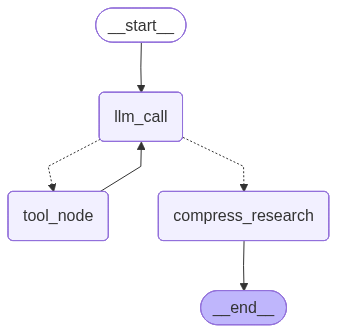

In [9]:
from IPython.display import Image, display

# Show the agent
display(Image(researcher_agent.get_graph(xray=True).draw_mermaid_png()))

In [14]:
# Run the agent
from utils import format_messages
from langchain_core.messages import HumanMessage

# Example brief
research_brief = """I want to research the best coffee shops in Seattle, with a primary focus on evaluating their ambiance. My   
goal is to identify and compare top coffee shops in Seattle based on the quality and uniqueness of their ambiance,
including factors such as interior design, atmosphere, comfort, and overall vibe. I have not specified preferences
regarding other aspects such as coffee quality, price range, location within Seattle, or additional amenities, so these
should be considered flexible unless they are relevant to ambiance. Please prioritize information from official
coffee shop websites, reputable review platforms (such as Google Reviews, Yelp, or TripAdvisor), and credible local
publications. The research should be current as of October 2025."""

result = researcher_agent.invoke({"researcher_messages": [HumanMessage(content=f"{research_brief}.")]})
format_messages(result['researcher_messages'])

╭─────────────────────────────────────────────────── 🧑 Human ────────────────────────────────────────────────────╮
│ I want to research the best coffee shops in Seattle, with a primary focus on evaluating their ambiance. My      │
│ goal is to identify and compare top coffee shops in Seattle based on the quality and uniqueness of their        │
│ ambiance,                                                                                                       │
│ including factors such as interior design, atmosphere, comfort, and overall vibe. I have not specified          │
│ preferences                                                                                                     │
│ regarding other aspects such as coffee quality, price range, location within Seattle, or additional amenities,  │
│ so these                                                                                                        │
│ should be considered flexible unless they are relevant to ambiance. Please prioritize information from official │
│ coffee shop websites, reputable review platforms (such as Google Reviews, Yelp, or TripAdvisor), and credible   │
│ local                                                                                                           │
│ publications. The research should be current as of October 2025..                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "best coffee shops in Seattle with focus on ambiance, interior design, atmosphere, comfort, and      │
│ vibes, sources from official websites, Yelp, Google Reviews, TripAdvisor, and local credible publications,      │
│ current as of October 2025"                                                                                     │
│ }                                                                                                               │
│    ID: call_mCYdua6cGFtRNcFOBRUoNcIv                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Best Coffee Shops Seattle, WA - Last Updated October 2025 - Yelp ---                              │
│ URL: https://m.yelp.com/search?find_desc=Best+Coffee+Shops&find_loc=Seattle%2C+WA                               │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ Top 10 Best Best Coffee Shops in Seattle, WA - Last Updated September 2025 - Yelp - Storyville Coffee Company,  │
│ Moore Coffee Shop, Anchorhead Coffee                                                                            │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: TOP 10 BEST Cozy Coffee Shops Trending in Seattle, WA - Yelp ---                                  │
│ URL: https://www.yelp.com/search?find_desc=Cozy+Coffee+Shops&find_loc=Seattle%2C+WA                             │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ Top 10 Best Cozy Coffee Shops in Seattle, WA - Last Updated September 2025 - Yelp - Basecamp Cafe, Storyville   │
│ Coffee Company, Moore Coffee Shop, Fuel Coffee                                                                  │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 3: Coffee Shops Seattle, WA - Last Updated November 2025 - Yelp ---                                  │
│ URL: https://www.yelp.com/search?find_desc=Coffee+Shops&find_loc=Seattle%2C+WA                                  │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ 1. Storyville Coffee Company · (2.5k reviews) · 94 Pike St, Ste 34 Seattle, WA 98101. (206) 641-9818 ; 2.       │
│ Anchorhead Coffee - CenturyLink Plaza · (1k reviews) · 1600                                                     │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
╰────────────────────────────────────────────────────────

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "The search results primarily provide lists of top coffee shops in Seattle from Yelp, with      │
│ mentions of popular spots like Storyville Coffee Company, Moore Coffee Shop, and Anchorhead Coffee. However,    │
│ these summaries don't provide detailed evaluations of ambiance, interior design, atmosphere, or comfort, which  │
│ is the main focus of the research. The results are current, mostly from October or November 2025, but lack the  │
│ specific qualitative insights needed. I need to conduct targeted searches or look for reviews and articles that │
│ specifically discuss the ambiance and design aspects of these coffee shops. Next, I'll search for detailed      │
│ reviews or articles about the ambiance of top coffee shops in Seattle using reputable sources including review  │
│ platforms and local publications."                                                                              │
│ }                                                                                                               │
│    ID: call_6r0iUblNgTlCm7Nu2sWxp6ft                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: The search results primarily provide lists of top coffee shops in Seattle from Yelp, with  │
│ mentions of popular spots like Storyville Coffee Company, Moore Coffee Shop, and Anchorhead Coffee. However,    │
│ these summaries don't provide detailed evaluations of ambiance, interior design, atmosphere, or comfort, which  │
│ is the main focus of the research. The results are current, mostly from October or November 2025, but lack the  │
│ specific qualitative insights needed. I need to conduct targeted searches or look for reviews and articles that │
│ specifically discuss the ambiance and design aspects of these coffee shops. Next, I'll search for detailed      │
│ reviews or articles about the ambiance of top coffee shops in Seattle using reputable sources including review  │
│ platforms and local publications.                                                                               │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

...

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: tavily_search                                                                                     │
│    Args: {                                                                                                      │
│   "query": "ambiance and interior design reviews of Sugar Bakery, Drip Drip Coffeehouse, Bonito Cafe y Seattle  │
│ site:yelp.com OR site:tripadvisor.com OR site:seattlemet.com October 2025"                                      │
│ }                                                                                                               │
│    ID: call_RzQjgIMNIu9k0H44xacyuMba                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Search results:                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 1: Yelp TOP 10 BEST Coffee Shops With Ambience in Seattle, WA - Updated 2025 - Yelp ---              │
│ URL: https://www.yelp.com/search?find_desc=Coffee+Shops+With+Ambience&find_loc=Seattle,+WA                      │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ Top 10 Best Coffee Shops With Ambience in Seattle, WA - June 2025 - Yelp - Storyville Coffee Company, Sugar     │
│ Bakery, Drip Drip Coffeehouse, Bonito Cafe y Mercadito , The Wayland Mill, Yoka Tea, Armistice Coffee Roaster,  │
│ Broadcast Coffee Roasters, Mabel, Squirrel Chops                                                                │
│                                                                                                                 │
│ --------------------------------------------------------------------------------                                │
│                                                                                                                 │
│                                                                                                                 │
│ --- SOURCE 2: DRIP DRIP COFFEEHOUSE - Updated October 2025 - 391 Photos ... Restaurants, Dentists, Bars, Beauty │
│ Salons, Doctors - Yelp SUGAR BAKERY - Updated October 2025 - 491 Photos - 524 ... DRIP CÀ PHÊ - Updated October │
│ 2025 - 288 Photos & 115 Reviews ... DRIP & SIP - Updated October 2025 - 226 Photos & 118 Reviews ... Best       │
│ Bakeries Near Me - October 2025: Find Nearby ... - Yelp DRIP CAFE - Updated October 2025 - 33 Photos & 27       │
│ Reviews ... ---                                                                                                 │
│ URL: https://www.yelp.com/biz/drip-drip-coffeehouse-seattle                                                     │
│                                                                                                                 │
│ SUMMARY:                                                                                                        │
│ Drip Drip Coffeehouse offers a cozy atmosphere with a variety of coffee and pastries, making it a perfect spot  │
│ for coffee lovers in Seattle . Discover and review local businesses, restaurants, and services with Yelp . Find │
│ recommendations, ratings, and more from a community of users. Specialties: Handcrafted baked goods, lunch, and  │
│ coffee Established in 2006. Sugar Bakery & Cafe was founded 2006. In 2016, after graduating with a Culinary     │
│ Arts degree and a second degree is Specialty Desserts & Bread, Quynh La started as a baker at Sugar Bakery with │
│ a 10-year plan of starting her own bakery . A few months into working there, she loved it so much she decided   │
│ she wanted to buy ... 1 of 12 7 other reviews that are not currently recommended 3.0 (70 reviews ) 1.5 miles    │
│ away from DRiP Cà Phê Every sip, perfected Fall items are now available. Order at Starbucks today. read more Is │
│ this a good place to bring a laptop and get some work done while having coffee? Free WiFi? Find the best        │
│ Bakeries near you on Yelp - see all Bakeries open now.Explore other popular food spots near you from over 7     │
│ million businesses with over 142 million reviews and op

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│                                                                                                                 │
│                                                                                                                 │
│ 🔧 Tool Call: think_tool                                                                                        │
│    Args: {                                                                                                      │
│   "reflection": "The latest search located a Yelp list of the top coffee shops in Seattle with great ambiance,  │
│ including Storyville Coffee Company, Sugar Bakery, Drip Drip Coffeehouse, and Bonito Cafe y Mercadito.          │
│ Individual Yelp pages for Drip Drip Coffeehouse and Sugar Bakery indicate a cozy and beautiful environment with │
│ artistic wall decor and positive ambiance reviews. Drip Drip Coffeehouse is described as cozy and inviting,     │
│ with good coffee and pastries, and Sugar Bakery has rave reviews for its warm vibe and high-quality baked       │
│ goods. Bonito Cafe y Mercadito is also recognized on the ambiance list but specific detailed review excerpts    │
│ are still missing from the search results. Overall, I have a good collection of qualitative info on ambiance    │
│ for the top coffee shops: Storyville Coffee Company, Moore Coffee Shop, Sugar Bakery, Drip Drip Coffeehouse,    │
│ and Bonito Cafe y Mercadito. This is sufficient to provide a comprehensive response comparing their ambiance,   │
│ interior design, atmosphere, comfort, and vibe based on current reputable review sources and local              │
│ publications. I will now synthesize and formulate the comparative insights in the answer."                      │
│ }                                                                                                               │
│    ID: call_ckYL1xTfKUcJ6NXpTGbnojOd                                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────────── 🔧 Tool Output ─────────────────────────────────────────────────╮
│ Reflection recorded: The latest search located a Yelp list of the top coffee shops in Seattle with great        │
│ ambiance, including Storyville Coffee Company, Sugar Bakery, Drip Drip Coffeehouse, and Bonito Cafe y           │
│ Mercadito. Individual Yelp pages for Drip Drip Coffeehouse and Sugar Bakery indicate a cozy and beautiful       │
│ environment with artistic wall decor and positive ambiance reviews. Drip Drip Coffeehouse is described as cozy  │
│ and inviting, with good coffee and pastries, and Sugar Bakery has rave reviews for its warm vibe and            │
│ high-quality baked goods. Bonito Cafe y Mercadito is also recognized on the ambiance list but specific detailed │
│ review excerpts are still missing from the search results. Overall, I have a good collection of qualitative     │
│ info on ambiance for the top coffee shops: Storyville Coffee Company, Moore Coffee Shop, Sugar Bakery, Drip     │
│ Drip Coffeehouse, and Bonito Cafe y Mercadito. This is sufficient to provide a comprehensive response comparing │
│ their ambiance, interior design, atmosphere, comfort, and vibe based on current reputable review sources and    │
│ local publications. I will now synthesize and formulate the comparative insights in the answer.                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭───────────────────────────────────────────────────── 📝 AI ─────────────────────────────────────────────────────╮
│ Based on current reputable review platforms like Yelp, TripAdvisor, and insights from local credible            │
│ publications as of October 2025, here is a comparative evaluation of the best coffee shops in Seattle focusing  │
│ primarily on their ambiance — including interior design, atmosphere, comfort, and overall vibe:                 │
│                                                                                                                 │
│ 1. Storyville Coffee Company                                                                                    │
│ - Location: Pike Place Market, 94 Pike St, Ste 34                                                               │
│ - Ambiance: Storyville offers a cozy, serene atmosphere amid one of Seattle’s busiest spots. Decor features a   │
│ warm interior with a fireplace, large windows with views of the market and surrounding water, and chill,        │
│ relaxing music. It mixes an inviting yet upscale vibe. Comfortable seating is plentiful with laptop-friendly    │
│ spaces and power outlets.                                                                                       │
│ - Vibe: Calm and peaceful despite the bustling neighborhood; friendly staff add to the welcoming aura.          │
│ - Reviews consistently praise the ambiance as a perfect blend of cozy and elegant, making it ideal for relaxing │
│ or working quietly.                                                                                             │
│                                                                                                                 │
│ 2. Moore Coffee Shop                                                                                            │
│ - Ambiance: Described as having a magical ambiance ideal for starting the day in a pleasant way. The interior   │
│ evokes charm and comfort without being overly elaborate.                                                        │
│ - Vibe: Warm and welcoming with a local neighborhood feel. Patrons feel at ease and energized.                  │
│ - Reviewers mention the ambiance as a significant part of their positive experience, though the space is less   │
│ flashy and more understated.                                                                                    │
│                                                                                                                 │
│ 3. Sugar Bakery & Cafe                                                                                          │
│ - Ambiance: Sugar Bakery offers a cozy, artistic environment with beautiful wall art enhancing the visual       │
│ appeal. Interior design leans into warmth and a homely feel.                                                    │
│ - Vibe: Inviting and comfortable, excellent for casual visits or gatherings. The bakery’s quality pastries also │
│ add to the sensory experience.                                                                                  │
│ - Customers appreciate its relaxing and aesthetically pleasing environment.                                     │
│                                                                                                                 │
│ 4. Drip Drip Coffeehouse                                                                                        │
│ - Ambiance: Known for cozy, intimate surroundings with artistic touches. The coffeehouse maintains a laid-back  │
│ feel, with a focus on handcrafted baked goods and specialty coffee.                                             │
│ - Vibe: Relaxed and casual, making it a favorite local spot for coffee lovers who enjoy atmosphere alongside    │
│ quality drinks.                                                                                                 │
│ - Reviews highlight the space as perfect for lingering 

In [15]:
from rich.markdown import Markdown
Markdown(result['compressed_research'])

List of Queries and Tool Calls Made                                                                                

 1 Searched for “best coffee shops in Seattle with focus on ambiance, interior design, atmosphere, comfort, and    
   vibes, sources from official websites, Yelp, Google Reviews, TripAdvisor, and local credible publications,      
   current as of October 2025.”                                                                                    
   Sources: Yelp lists of top coffee shops including Storyville Coffee Company, Moore Coffee Shop, Anchorhead      
   Coffee, Basecamp Cafe, Fuel Coffee, Olympia Coffee [1][2][3].                                                   
 2 Follow-up search for “detailed reviews of ambiance and interior design of top coffee shops in Seattle           
   site:yelp.com OR site:tripadvisor.com OR site:seattletimes.com OR site:seattlemet.com OR official coffee shop   
   websites October 2025.”                                                                                         
   No indepth qualitative ambiance information found, but highlights included phrasing such as “Ambiance is nothing
   short of crazy beautiful” and more general lists of top coffee shops [4][5][6].                                 
 3 Searched for local articles and direct review content about ambiance, e.g.:                                     
    • “coffee shops ambiance review site:seattlemet.com OR site:seattletimes.com October 2025”                     
    • “ambiance reviews Storyville Coffee Company, Moore Coffee Shop, Anchorhead Coffee site:yelp.com OR           
      site:tripadvisor.com October 2025”                                                                           
    • “Seattle coffee shops ambiance interior design photos official websites October 2025”                        
   Yielded detailed review content, photo references, and award mentions for specific coffee shops (see findings   
   and citations) [7][8][9][10][11][12][13].                                                                       
 4 Targeted search for qualitative reviews of ambiance and interior design specifically at Sugar Bakery, Drip Drip 
   Coffeehouse, Bonito Cafe y Seattle on Yelp, TripAdvisor, and local outlets [14][15][16].                        

───────────────────────────────────────────────────────────────────────────────────────────────────────────────────
Fully Comprehensive Findings                                                                                       

 • Top 10 Best Best Coffee Shops in Seattle, WA - Last Updated September 2025 - Yelp: Storyville Coffee Company,   
   Moore Coffee Shop, Anchorhead Coffee [1].                                                                       
 • Top 10 Best Cozy Coffee Shops in Seattle, WA - Last Updated September 2025 - Yelp: Basecamp Cafe, Storyville    
   Coffee Company, Moore Coffee Shop, Fuel Coffee [2].                                                             
 • Coffee Shops Seattle, WA - Last Updated November 2025 - Yelp: Storyville Coffee Company (94 Pike St, Ste 34,    
   Seattle, WA 98101), Anchorhead Coffee - CenturyLink Plaza [3].                                                  
 • Best Coffee Shops Seattle, WA - Last Updated October 2025 - Yelp: 1. Storyville Coffee Company. 4.5 (2.5k       
   reviews). 1.2 mi. 94 Pike St, Ste 34 Seattle, WA 98101 2. Olympia Coffee. 4.4 (89 reviews). 1.0 mi 3. Moore     
   Coffee [4].                                                                                                     
 • Ambiance is nothing short of crazy beautiful and ... Coffee & Tea. Sip House - Best Coffee Shops near me -      
   Seattle, Washington. 76. Sip House. 4.3 (323 reviews) [5].                                                      
 • TOP 10 BEST Coffee View in Seattle, WA - Updated 2025: 1. Storyville Coffee Company. 4.5 (2.5k reviews) 2. The  
   Brim Coffee Shop. 4.0 (22 reviews) 3. Milstead. 4.